     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  proanthocyan

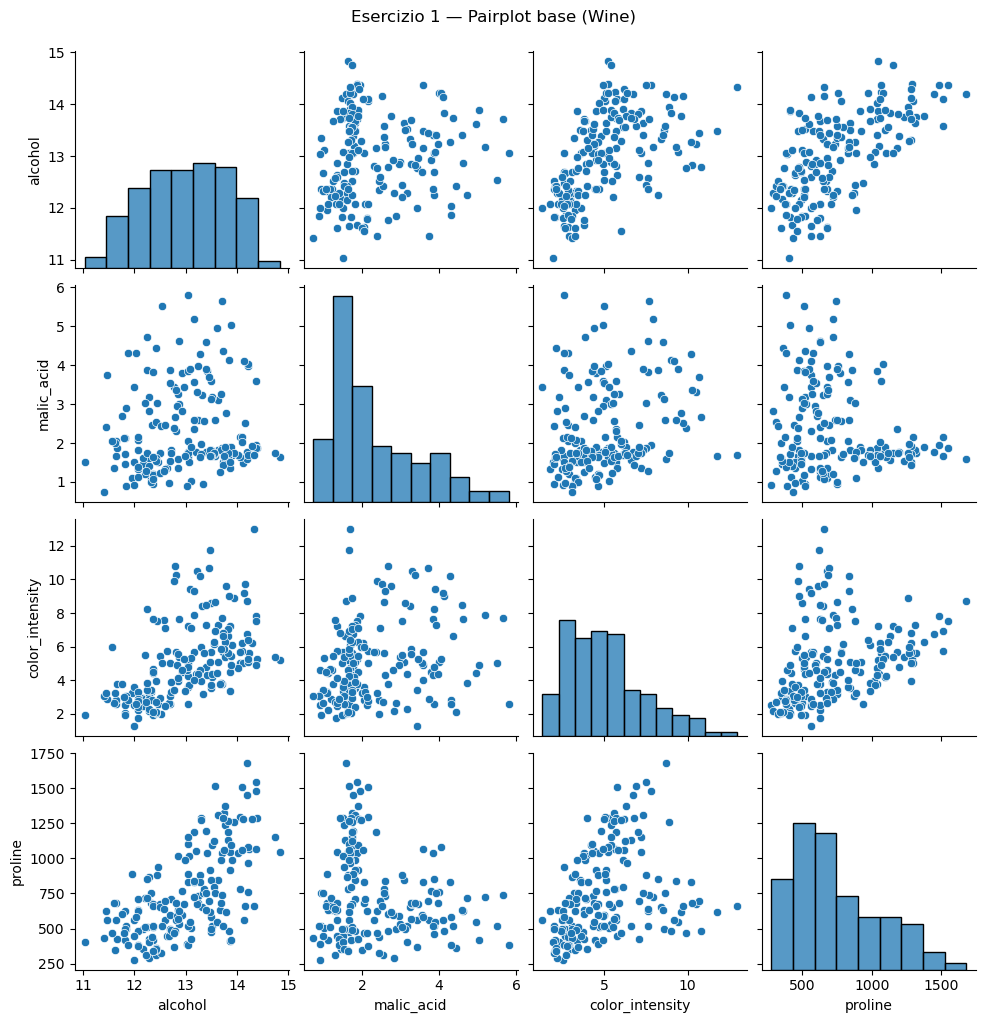

In [3]:
# - Esercizio 1 — Pairplot

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.frame
cols = ["alcohol", "malic_acid", "color_intensity", "proline"]

print(df)


sns.pairplot(df[cols])
plt.suptitle("Esercizio 1 — Pairplot base (Wine)", y=1.02)
plt.show()

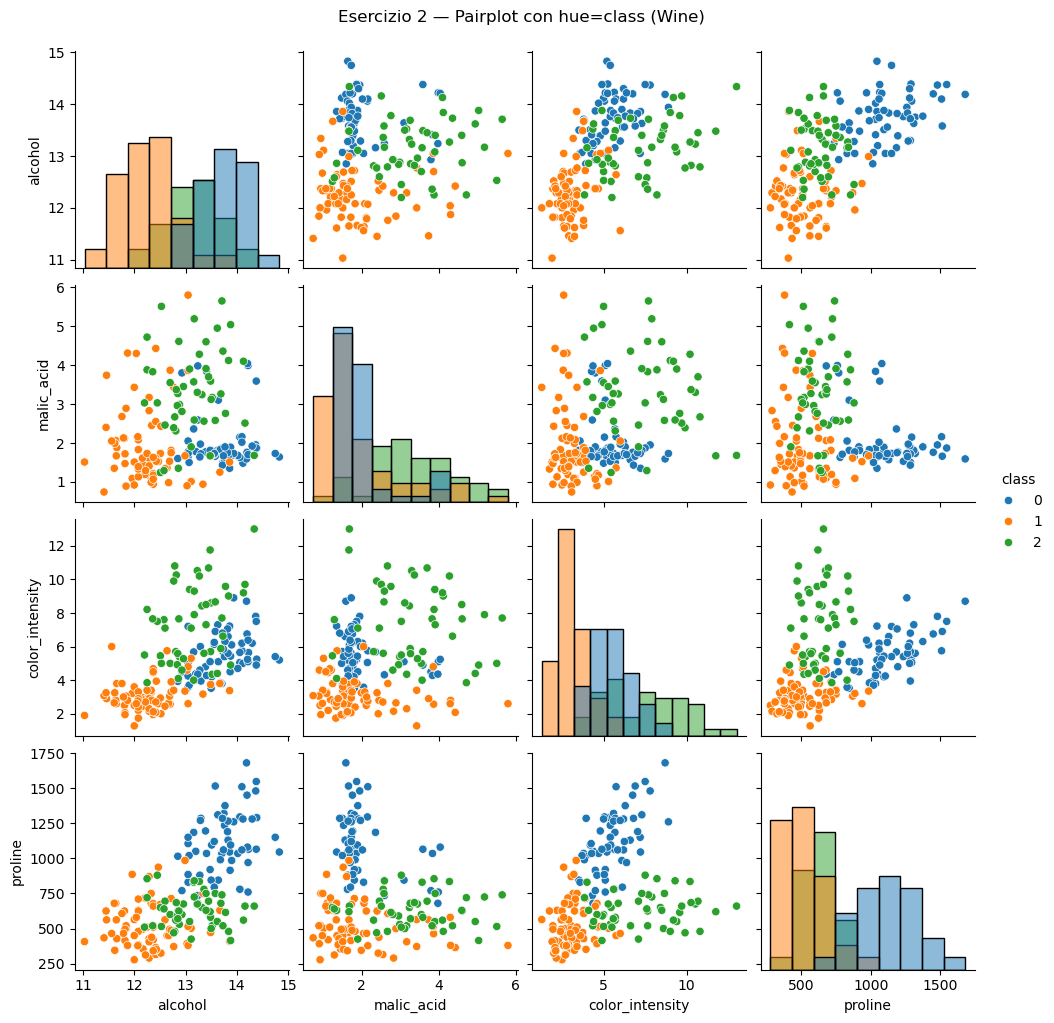

In [ ]:
# - Esercizio 2 — Aggiungere hue per distinguere categorie (diag : usiamo istograma)

df2 = df.copy()
df2["class"] = df2["target"].astype(str)

sns.pairplot(df2[cols + ["class"]], hue="class", diag_kind="hist")
plt.suptitle("Esercizio 2 — Pairplot con hue=class (Wine)", y=1.02)
plt.show()



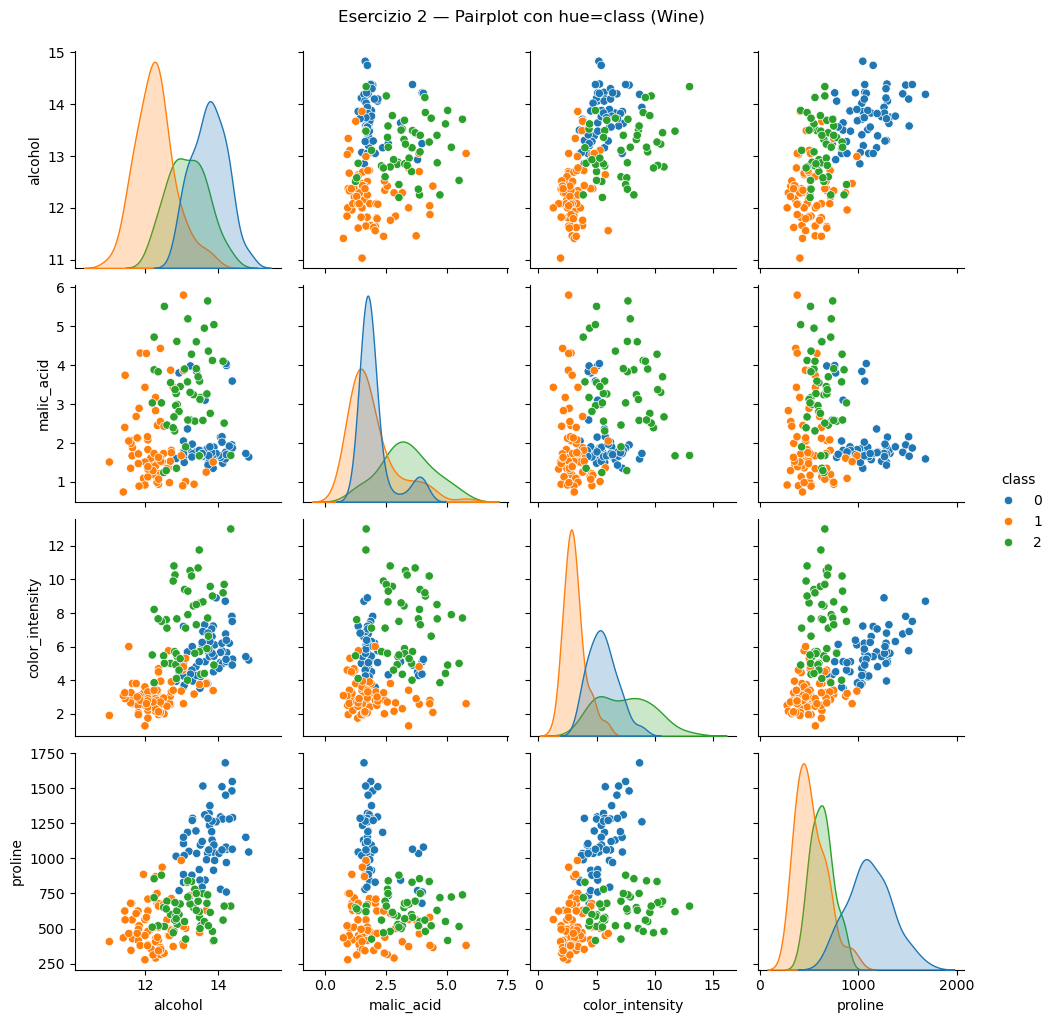

In [ ]:
# - Esercizio 2 — Aggiungere hue per distinguere categorie (usoiamo KDE)

df2 = df.copy()
df2["class"] = df2["target"].astype(str)

sns.pairplot(df2[cols + ["class"]], hue="class", diag_kind="kde")
plt.suptitle("Esercizio 2 — Pairplot con hue=class (Wine)", y=1.02)
plt.show()



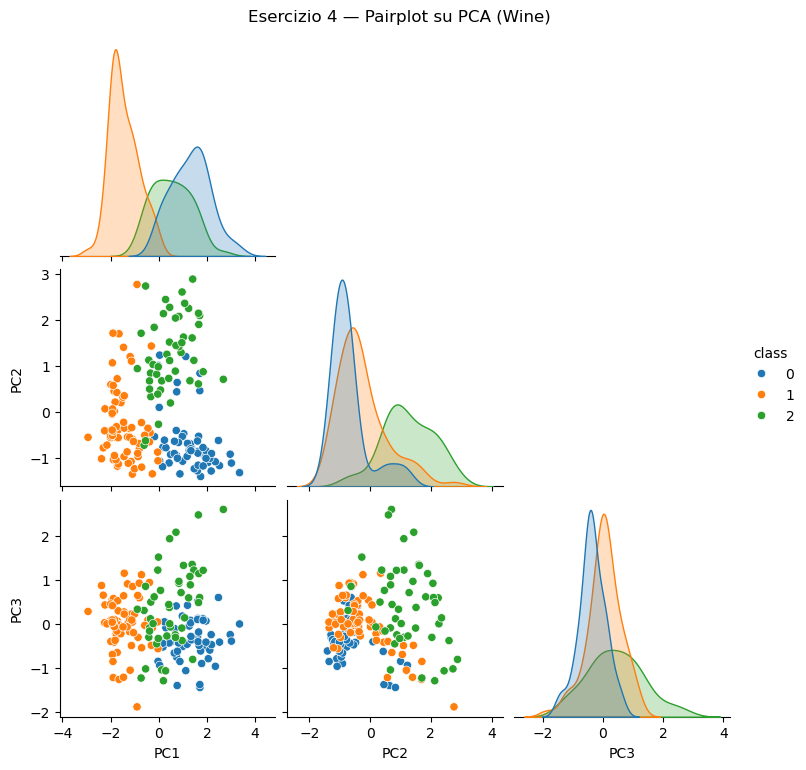

Varianza spiegata: [0.50566236 0.29702934 0.12769299]


In [5]:
# - Esercizio 4 — PCA e pairplot sulle componenti principali

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df2[cols].to_numpy()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3, random_state=0)
pcs = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3"])
df_pca["class"] = df2["class"].to_numpy()

sns.pairplot(df_pca, hue="class", diag_kind="kde", corner=True)
plt.suptitle("Esercizio 4 — Pairplot su PCA (Wine)", y=1.02)
plt.show()

print("Varianza spiegata:", pca.explained_variance_ratio_)